   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

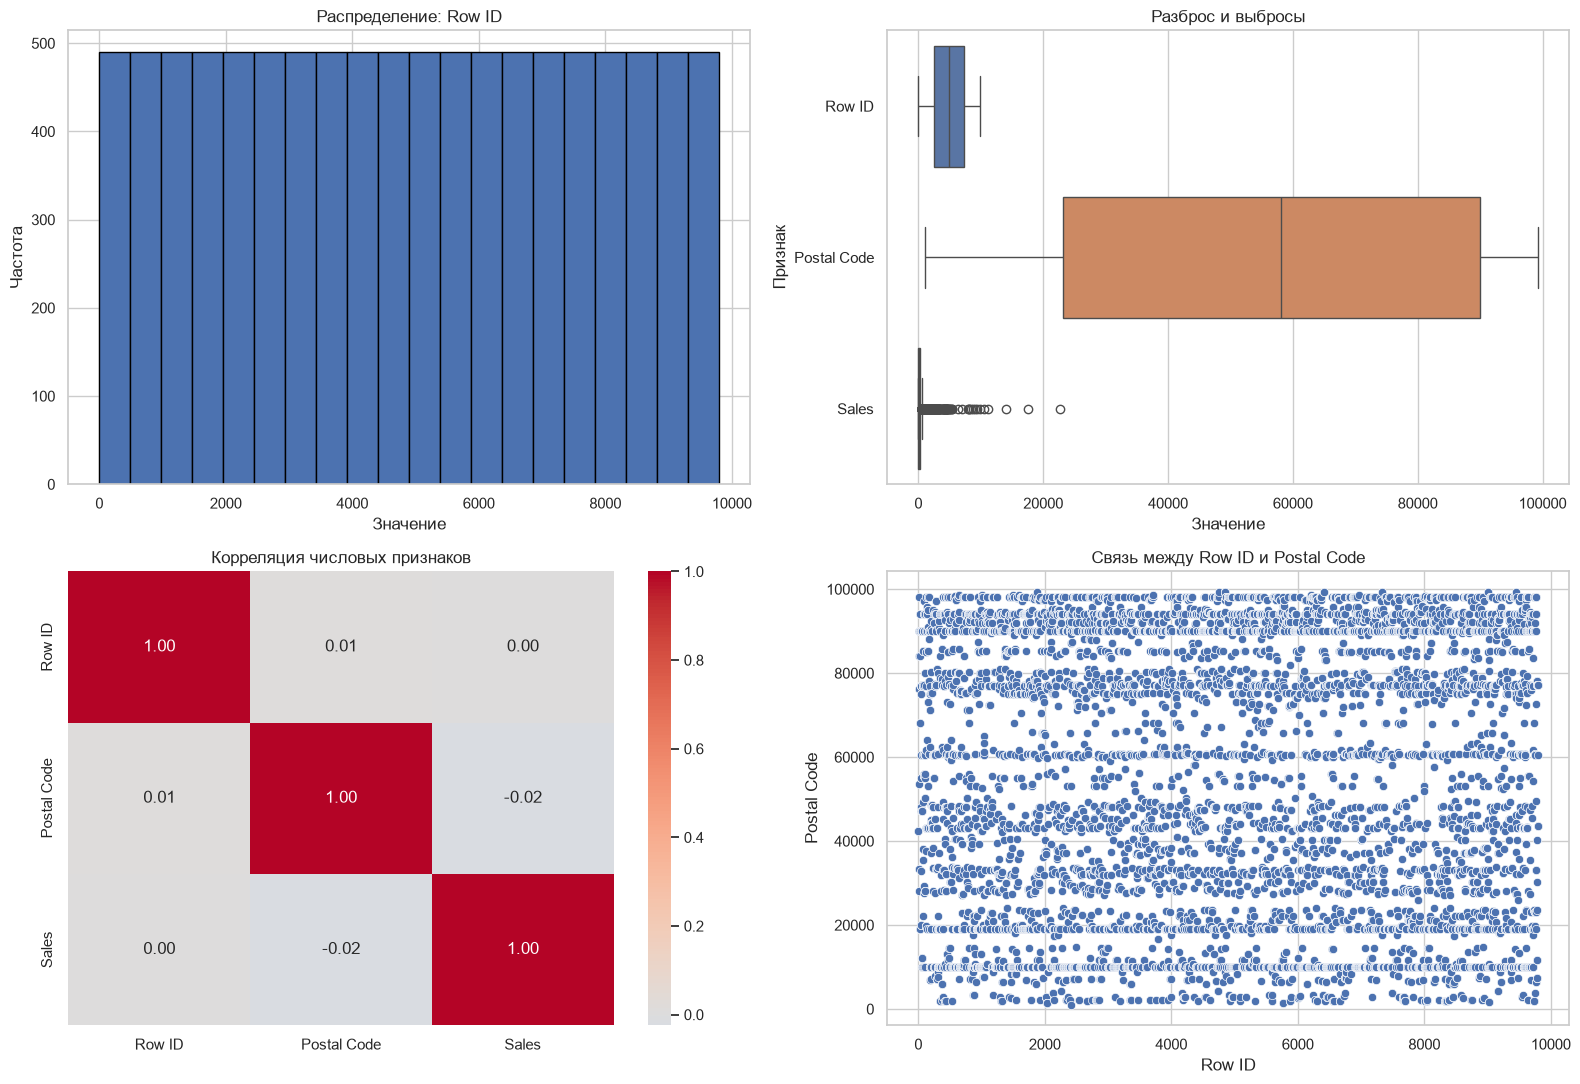

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('data.csv')
print(data.head())
# Размер таблицы
print("\nРазмер таблицы:")
print(f"Строк: {data.shape[0]}, столбцов: {data.shape[1]}")

# Названия столбцов
print("\nСтолбцы:")
print(data.columns.tolist())

# Типы данных и количество непустых значений
print("\nИнформация о DataFrame:")
data.info()

# Описательная статистика числовых столбцов
print("\nСтатистика:")
print(data.describe())

# Количество пропущенных значений
missing = data.isna().sum()

print("\nПропуски по столбцам:")
print(missing)

# Процент пропусков
missing_percent = (data.isna().mean() * 100).round(2)

print("\nПроцент пропусков:")
print(missing_percent)

# Выбираем только числовые столбцы
numeric_data = data.select_dtypes(include="number")

# Основные статистические характеристики
statistics = numeric_data.describe().T

# Добавляем размах: максимум - минимум
statistics["range"] = statistics["max"] - statistics["min"]

# Округляем результаты
statistics = statistics.round(2)

print("\nОсновные статистические характеристики:")
print(statistics)

# Оставляем только числовые столбцы
numeric_data = data.select_dtypes(include="number")

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

'''# 1. Гистограммы
numeric_data.hist(
    ax=axes[0, 0],
    bins=20,
    edgecolor="black"
)
axes[0, 0].set_title("Распределение числовых признаков")
axes[0, 0].set_xlabel("Значение")
axes[0, 0].set_ylabel("Частота")'''
# 1. Гистограмма первого числового столбца
column = numeric_data.columns[0]

axes[0, 0].hist(
    numeric_data[column].dropna(),
    bins=20,
    edgecolor="black"
)

axes[0, 0].set_title(f"Распределение: {column}")
axes[0, 0].set_xlabel("Значение")
axes[0, 0].set_ylabel("Частота")

# 2. Boxplot
sns.boxplot(
    data=numeric_data,
    orient="h",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Разброс и выбросы")
axes[0, 1].set_xlabel("Значение")
axes[0, 1].set_ylabel("Признак")

# 3. Корреляционная матрица
corr = numeric_data.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Корреляция числовых признаков")

# 4. Диаграмма рассеяния первых двух числовых признаков
if numeric_data.shape[1] >= 2:
    x_column = numeric_data.columns[0]
    y_column = numeric_data.columns[1]

    sns.scatterplot(
        data=numeric_data,
        x=x_column,
        y=y_column,
        ax=axes[1, 1]
    )

    axes[1, 1].set_title(
        f"Связь между {x_column} и {y_column}"
    )
    axes[1, 1].set_xlabel(x_column)
    axes[1, 1].set_ylabel(y_column)
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных из CSV-файла
data = pd.read_csv('data.csv')

# Предварительный анализ данных
# Проверка наличия пропущенных значений
missing_values = data.isnull().sum()
print("Пропущенные значения:")
print(missing_values)

print(data)

# Оценка статистических характеристик данных
statistics = data.describe()
print("Статистические характеристики:")
print(statistics)

# Визуализация данных
plt.figure(figsize=(10, 6))
plt.hist(data['Price'], bins=10, edgecolor='black')
plt.xlabel('Продажи')
plt.ylabel('Частота')
plt.title('Распределение продаж')
plt.show()

Пропущенные значения:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608 

KeyError: 'Price'

<Figure size 1000x600 with 0 Axes>